# Wilson-Cowan Third-Order Additive (TA) Model - Sigmoid Slope vs Coupling

**Model:** Parameter sweep of sigmoid slope (a_E) and coupling strength K for TA model

## Overview

This notebook explores the relationship between sigmoid slope (a_E) and coupling strength K in the Third-Order Additive model. It performs a 2D parameter sweep to understand how changes in neuronal gain (sigmoid steepness) interact with coupling strength to produce different dynamical regimes and higher-order statistical structures.

## Key Sections

- **Parameter sweep in (a_E, K) space:** Systematic exploration across both sigmoid slope and coupling parameters
- **Oscillation and metric computation:** Detect oscillations and compute statistical measures for each parameter combination

---


In [1]:
import sys
import os
sys.path.append('../')  # Ensure Python can find the 'Scripts' folder

#from Scripts.parameters import *
#from Scripts.parameters_random import *
from Scripts.parameters import *
from Scripts.dynamics import *
from Scripts.simulation import *
from Scripts.oscillation_detection import *
from Scripts.metrics import *
from Scripts.visualization import *

print("Functions loaded successfully.")

# Parameter ranges for oscillation detection
P_values = np.linspace(1.0, 10.0, 20)
K_values = np.linspace(0.0, 1.0, 20)
K3_values = np.linspace(0.0, 1.0, 20)

Stable Rank  (M): 1.50
Nuclear Rank (M): 2.00
Effective Rank (95% energy, M): 3
Functions loaded successfully.


---
## **6. Model with Stochastic Noise and Higher-Order Interactions**
We add stochastic noise to the excitatory population (E) using the Euler-Maruyama method with higher-order interactions.

To include biological noise, we extend the excitatory population dynamics using the **Euler-Maruyama method**:

$$
E_i(t + \Delta t) = E_i(t) + \frac{\Delta t}{\tau_E} \left(-E_i(t) + S\left(c_{EE} E_i - c_{IE} I_i + P + K_3 \sum_{j,k} T_{ijk} E_j E_k\right)\right) + \frac{\sigma_E \sqrt{\Delta t}}{\tau_E} \xi_i
$$

- $(\sigma_E)$: Noise intensity for the excitatory population.
- $(\xi_i \sim \mathcal{N}(0, 1))$: Gaussian white noise.

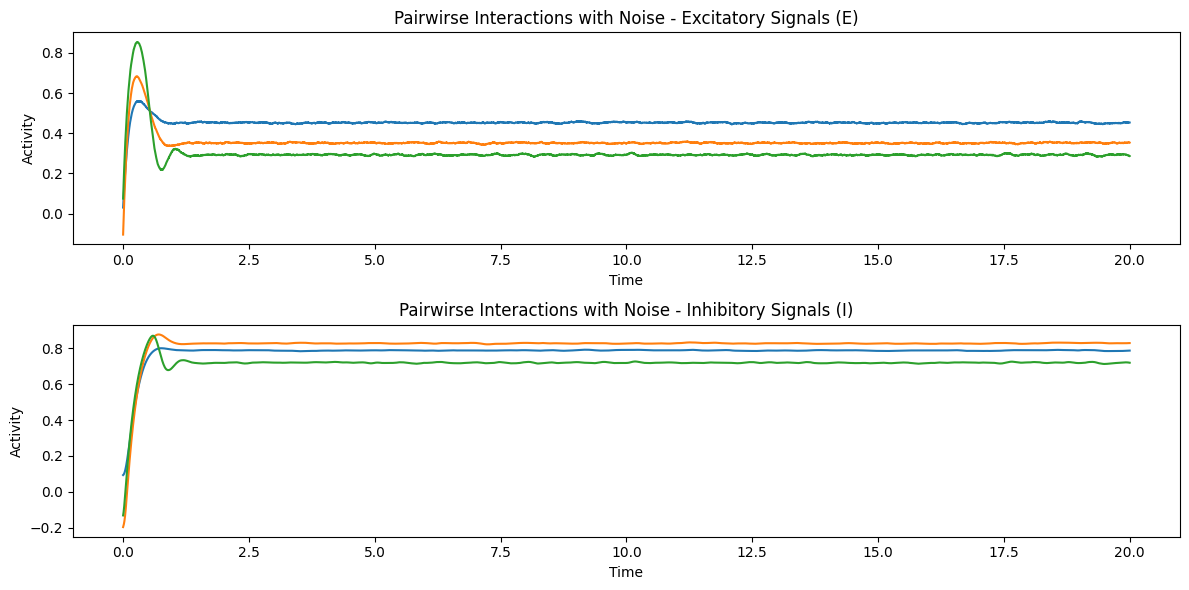

Total timesteps: 20000
Analysis timesteps: 19001

Node 0:
  E: mean=0.4524, std=0.0024, range=[0.4443, 0.4602]
  I: mean=0.7866, std=0.0017, range=[0.7822, 0.7908]

Node 1:
  E: mean=0.3515, std=0.0025, range=[0.3389, 0.3590]
  I: mean=0.8260, std=0.0018, range=[0.8204, 0.8313]

Node 2:
  E: mean=0.2927, std=0.0037, range=[0.2824, 0.3228]
  I: mean=0.7184, std=0.0026, range=[0.6976, 0.7325]


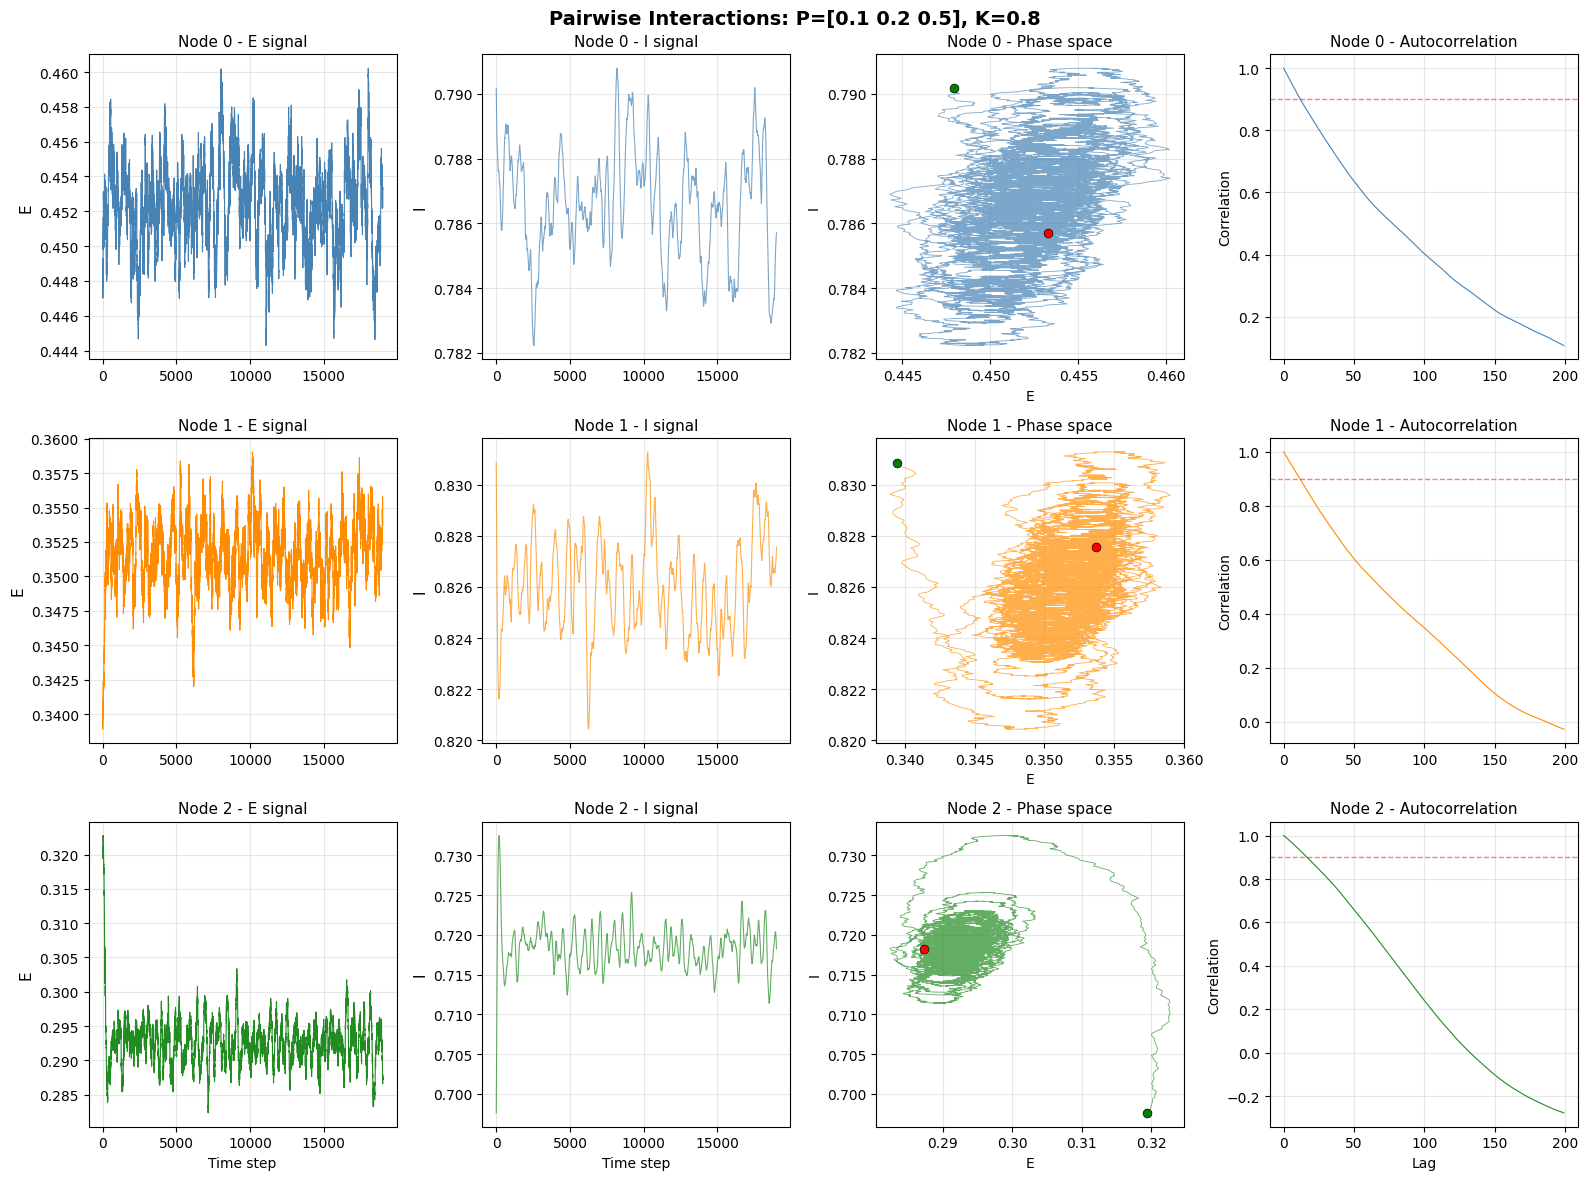

In [2]:
# Simulation parameters with noise
A_sim = np.array([0.1, 0.2, 0.5])  # P per node
#K_sim = 0.5
#P_sim = np.array([0, 0, 0])  # P per node
K_sim = 0.8


# Initial state
#initial state
seed = 42
rng = np.random.default_rng(seed)
state0 = 0.1 * rng.standard_normal(2 * N_nodes)
T=20
sigma_E = 0.03

# Simulation with noise using the existing function
t, states = simulate_wc_higher_order_stochastic_a(state0, A_sim, K_sim, T_ho, T, dt, sigma_E=0.01, P=7)
# Extract signals
E = states[:, :N_nodes]
I = states[:, N_nodes:]

# Visualization using the existing function
plot_signals(t, E, I, title="Pairwirse Interactions with Noise")
# Visualization using the existing function
plot_detailed_signals(t, states, N_nodes, P_sim=A_sim, K_sim=K_sim, title="Pairwise Interactions")



---
## **7. Oscillation Detection in $(P \times K$) Space** with noise
We perform a parameter sweep to detect oscillations in the $(P \times K$) space.


In [2]:
A_values = np.linspace(0.5, 3, 20)
K_values = np.linspace(0.0, 1.0, 20)
K3_values = np.linspace(0.0, 1.0, 20)
sigma_E = 0.03
#T=150 # 2 minutes
T=375


# Matrices to store metrics with noise
TC_map_noise = np.zeros((len(P_values), len(K_values)))
DTC_map_noise = np.zeros((len(P_values), len(K_values)))
Cumulant_map_noise = np.zeros((len(P_values), len(K_values)))
PowerCorr_map_noise = np.zeros((len(P_values), len(K_values)))
Entropy_map_noise = np.zeros((len(P_values), len(K_values)))  # Nueva métrica
Entropy_map_skew = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica
Entropy_map_kurt = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica

TC_ksg_map = np.zeros((len(A_values), len(K3_values)))
DTC_ksg_map = np.zeros((len(A_values), len(K3_values)))
Oinfo_ksg_map = np.zeros((len(A_values), len(K3_values)))


# Matrix to store oscillation detection with noise
oscillation_map_noise = np.zeros((len(P_values), len(K3_values)), dtype=int)
# mean_map = np.zeros((len(P_values), len(K_values), N_nodes))

#initial state
seed = 42
rng = np.random.default_rng(seed)
state0 = 0.1 * rng.standard_normal(2 * N_nodes)

# Create folder for raw simulated signals
sim_folder = '../simulations/3rd_order_additive_ak'
os.makedirs(sim_folder, exist_ok=True)

for i, A_val in enumerate(A_values):
    for j, K3_val in enumerate(K3_values):
        # Simulation with noise using the existing function for higher-order interactions
        # t, states = simulate_wc_stochastic(state0, P_val, K3_val, M, T, dt, sigma_E=sigma_E, higher_order=True, T_ho=T_ho)
        A_vec = np.array([A_val, A_val, A_val])
        #t, states = simulate_wc_stochastic(state0, P_vec, K3_val, M, T, dt, sigma_E = sigma_E, higher_order=True, T_ho=T_ho)
        t, states = simulate_wc_higher_order_stochastic_a(state0, A_vec, K3_val, T_ho, T, dt, sigma_E, P=7)
    
        start_idx = int(0.2 * len(t))
        E_node = states[start_idx:, :N_nodes]
        I_node = states[start_idx:, N_nodes:]

        # Oscillation detection using the existing function
        is_lc1, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        is_lc2, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        is_lc3, _, _, _ = detect_limit_cycle_poincare(E_node[:, 0], I_node[:, 0], dt, threshold_ratio=0.05, period_cv_threshold=0.05)
        oscillation_map_noise[i, j]  = int((is_lc1==True) and (is_lc2==True) and (is_lc3==True))

        # quitar transiente (ej. mitad inicial)
        # cut = int(0.5 * len(t))
        # E_ss = E_node[cut:, :]
        # mean firing per node
        # mean_map[i, j, :] = np.mean(E_ss, axis=0)


        # Remove transient
        E = states[start_idx:, :N_nodes]

        # Data matrix for higher-order metrics
        X = E.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics using the existing functions
        TC_map_noise[i, j] = TC_gauss(Sigma)
        DTC_map_noise[i, j] = DTC_gauss(Sigma)
        skew, kurt = dev_gauss(X)  # Cálculo de la entropía
        Entropy_map_skew[i, j] = skew
        Entropy_map_kurt[i, j] = kurt
        #Entropy_map_noise[i, j] = dev_gauss(Sigma)  # Cálculo de la entropía
        if X.shape[1] == 3:
            Cumulant_map_noise[i, j] = cumulants(X)
            PowerCorr_map_noise[i, j] = powercorr(X)

        # --- KSG non-parametric metrics ---
        if X.shape[1] == 3:
            TC_ksg_map[i, j] = TC_ksg(X)
            DTC_ksg_map[i, j] = DTC_ksg(X)
            Oinfo_ksg_map[i, j] = Oinfo_ksg(X)

        # --- Save raw simulated signals ---
        I_node_save = states[start_idx:, N_nodes:]
        np.savez_compressed(
            sim_folder + '/signals_i' + str(i).zfill(2) + '_j' + str(j).zfill(2) + '.npz',
            E=E, I=I_node_save,
            row_val=A_val, col_val=K3_val
        )

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing function
# plot_oscillation_map(oscillation_map_noise, P_values, K3_values, title="Oscillation Detection (P-K3) with Noise")

# Visualization using the existing functions

#cleaing the matrix
TC_clean = clean_rowwise_signed(TC_map_noise, n_std=2)
DTC_clean = clean_rowwise_signed(DTC_map_noise, n_std=2)
Cumulant_clean = clean_rowwise_signed(Cumulant_map_noise,n_std=2)
PowerCorr_clean = clean_rowwise_signed(PowerCorr_map_noise,n_std=2)
Skew_clean = clean_rowwise_signed(Entropy_map_skew,n_std=2)
Kurt_clean = clean_rowwise_signed(Entropy_map_kurt,n_std=2)

TC_ksg_clean = clean_rowwise_signed(TC_ksg_map, n_std=2)
DTC_ksg_clean = clean_rowwise_signed(DTC_ksg_map, n_std=2)
Oinfo_ksg_clean = clean_rowwise_signed(Oinfo_ksg_map, n_std=2)

# visualization the matrix cleaned
plot_metrics_contour(oscillation_map_noise, A_values, K3_values, title="Oscilation detection")

plot_metrics_contour(TC_clean, A_values, K3_values, title="Total Correlation (TC) witht Noise")
plot_metrics_contour(DTC_clean, A_values, K3_values, title="Dual Total Correlation (DTC) witht Noise")
plot_metrics_contour(Cumulant_clean, A_values, K3_values, title="Third-Order Cumulant witht Noise")
plot_metrics_contour(PowerCorr_clean, A_values, K3_values, title="Triple Power Correlation witht Noise")
plot_metrics_contour(Skew_clean, A_values, K3_values, title="skew with Noise")
plot_metrics_contour(Kurt_clean, A_values, K3_values, title="Kurt with Noise")

plot_metrics_contour(TC_ksg_clean, A_values, K3_values, title="TC KSG with Noise")
plot_metrics_contour(DTC_ksg_clean, A_values, K3_values, title="DTC KSG with Noise")
plot_metrics_contour(Oinfo_ksg_clean, A_values, K3_values, title="O-info KSG with Noise")


#os.makedirs("results", exist_ok=True)
np.savez_compressed(
    "../results/metrics_Coupling_noise_a.npz",
    oscillation_map=oscillation_map_noise,
    TC=TC_clean,
    DTC=DTC_clean,
    cumulant=Cumulant_clean,
    powercorr=PowerCorr_clean,
    skew=Skew_clean,
    kurt=Kurt_clean,
    TC_ksg=TC_ksg_clean,
    DTC_ksg=DTC_ksg_clean,
    Oinfo_ksg=Oinfo_ksg_clean,
    P=P_values,
    K3=K3_values
)


np.savez_compressed(
    "../results/raw_metrics_Coupling_noise_a.npz",
    oscillation_map=oscillation_map_noise,
    TC=TC_map_noise,
    DTC=DTC_map_noise,
    cumulant=Cumulant_map_noise,
    powercorr=PowerCorr_map_noise,
    skew=Entropy_map_skew,
    kurt=Entropy_map_kurt,
    TC_ksg=TC_ksg_map,
    DTC_ksg=DTC_ksg_map,
    Oinfo_ksg=Oinfo_ksg_map,
    P=P_values,
    K3=K3_values
)

Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


In [ ]:
import os
#os.makedirs("results", exist_ok=True)
np.savez_compressed(
    "../results/metrics_Coupling_noise_a.npz",
    oscillation_map=oscillation_map_noise,
    TC=TC_clean,
    DTC=DTC_clean,
    cumulant=Cumulant_clean,
    powercorr=PowerCorr_clean,
    skew=Skew_clean,
    kurt=Kurt_clean,
    P=P_values,
    K3=K3_values
)

In [5]:
import plotly.graph_objects as go
import numpy as np

def plot_metrics_contour(matrix, P_values, K_values, title="Metric Map",
                         colorscale="Inferno", n_contours=15, horizontal_lines=False,P1=0,P2=0):

    z_min = np.nanmin(matrix)
    z_max = np.nanmax(matrix)

    fig = go.Figure(data=go.Contour(
        z=matrix,
        x=K_values,
        y=P_values,
        colorscale=colorscale,
        contours=dict(
            start=z_min,
            end=z_max,
            size=(z_max - z_min) / n_contours,
            coloring='heatmap',
            showlines=True
        ),
        colorbar=dict(
            thickness=12,
            len=0.8
        )
    ))

    if horizontal_lines:
        # líneas horizontales
        fig.add_hline(y=P1, line=dict(color="lightblue", width=3), line_dash="dash")
        fig.add_hline(y=P2, line=dict(color="lightblue", width=3), line_dash="dash")
    
    fig.update_layout(
        title=title,
        xaxis_title='K',
        yaxis_title='P',
        width=500,
        height=400,
        margin=dict(l=60, r=40, t=50, b=50)
    )

    fig.show()

metrics = ["oscillation_map","TC","DTC","cumulant","powercorr","skew","kurt"]
pairwise = np.load("../results/metrics_Coupling_noise.npz")
for m in metrics:
    plot_metrics_contour(pairwise[m], pairwise["P"], pairwise["K3"], title=f"{m} with Noise",horizontal_lines=True,P1=5,P2=9)